In [1]:
%cd /content
!rm -rf cnn-ai-image-generalization
!git clone https://github.com/LeylaEynullazada/cnn-ai-image-generalization.git
%cd cnn-ai-image-generalization

/content
Cloning into 'cnn-ai-image-generalization'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 71 (delta 28), reused 38 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 23.61 KiB | 7.87 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/cnn-ai-image-generalization


# Real vs Fake Image Classification — Milestone 1

## Project Goal
Classify images as real or AI-generated (fake) using a CNN.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install dependencies
!pip install -q torch torchvision numpy matplotlib tqdm scikit-learn

In [4]:
# Set data path: "." for local or Colab with data in repo. For Colab+Drive, mount and set path.
DATA_DIR = "/content/drive/MyDrive/dataset_subset"

In [5]:
import torch
from src.dataset import get_dataloaders
from src.model import get_model
from src.train import train_full, validate
from src.evaluate import evaluate, get_metrics, plot_confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 32
IMAGE_SIZE = 128
train_loader, test_loader, classes = get_dataloaders(
    data_dir=DATA_DIR, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, num_workers=0
)
print("Classes:", classes, "| Train batches:", len(train_loader), "| Test batches:", len(test_loader))

Device: cuda
Classes: ['fake_subset', 'real_subset'] | Train batches: 63 | Test batches: 6


## Experiment 1: Baseline CNN

Train baseline CNN (5 epochs; will be increased for milestone2, when the whole dataset will be used)

In [6]:
model1 = get_model(num_classes=2, dropout=0.3)
history1 = train_full(
    model1, train_loader, test_loader,
    num_epochs=5, lr=1e-3, device=device,
    save_path="checkpoints/exp1_baseline.pth"
)

Train: 100%|██████████| 63/63 [05:08<00:00,  4.90s/it, acc=67.5, loss=0.823]


Epoch 1/5 | Train Loss: 0.6147 Acc: 67.47% | Val Loss: 0.6082 Acc: 66.15%


Train: 100%|██████████| 63/63 [03:17<00:00,  3.13s/it, acc=69.3, loss=0.665]


Epoch 2/5 | Train Loss: 0.6000 Acc: 69.28% | Val Loss: 0.5504 Acc: 70.83%


Train: 100%|██████████| 63/63 [03:21<00:00,  3.21s/it, acc=70.5, loss=0.768]


Epoch 3/5 | Train Loss: 0.5839 Acc: 70.48% | Val Loss: 0.5445 Acc: 72.92%


Train: 100%|██████████| 63/63 [03:23<00:00,  3.23s/it, acc=71.4, loss=0.908]


Epoch 4/5 | Train Loss: 0.5781 Acc: 71.44% | Val Loss: 0.5539 Acc: 72.92%


Train: 100%|██████████| 63/63 [03:24<00:00,  3.25s/it, acc=71, loss=0.422]


Epoch 5/5 | Train Loss: 0.5712 Acc: 70.98% | Val Loss: 0.5138 Acc: 71.88%


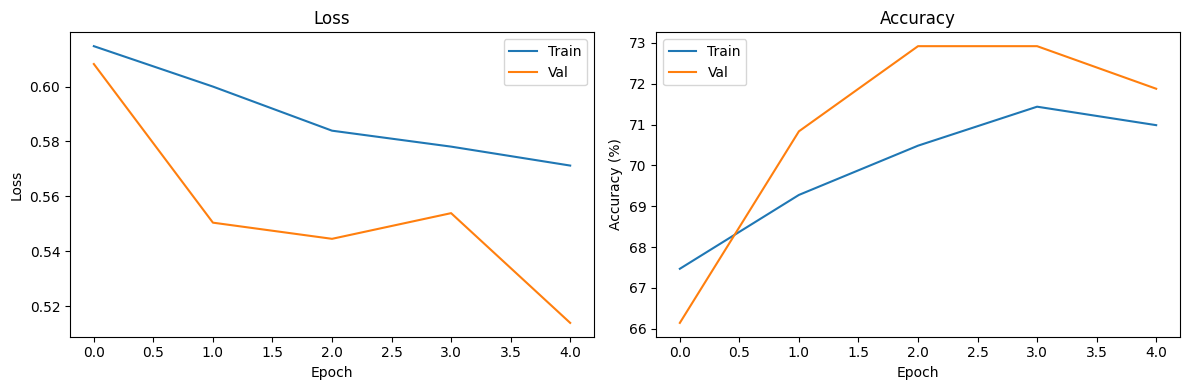

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history1["train_loss"], label="Train")
axes[0].plot(history1["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss")

axes[1].plot(history1["train_acc"], label="Train")
axes[1].plot(history1["val_acc"], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].set_title("Accuracy")
plt.tight_layout()
plt.show()

Test Accuracy: 0.7291666666666666 | Precision: 0.7295652173913043 Recall: 0.7291666666666667 F1: 0.7290490664350847
Confusion Matrix:
 [[72 24]
 [28 68]]
              precision    recall  f1-score   support

 fake_subset       0.72      0.75      0.73        96
 real_subset       0.74      0.71      0.72        96

    accuracy                           0.73       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.73      0.73      0.73       192



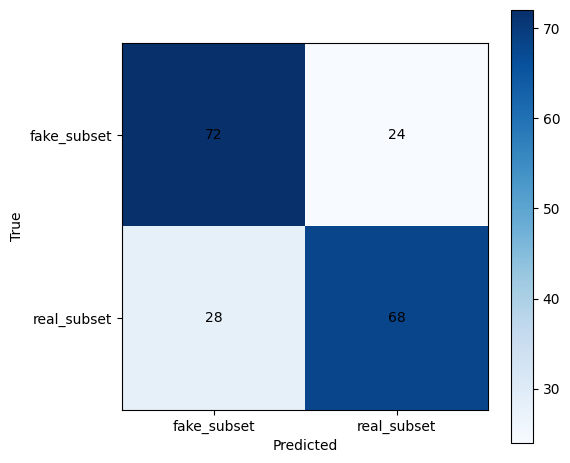

In [15]:
# Load best model and evaluate
model1.load_state_dict(torch.load("checkpoints/exp1_baseline.pth", map_location=device)["model_state_dict"])
y_true, y_pred, y_probs = evaluate(model1, test_loader, device)
acc, cm, report = get_metrics(y_true, y_pred, list(classes))
p, r, f1 = precision_recall_f1(y_true, y_pred)
print("Test Accuracy:", acc, "| Precision:", p, "Recall:", r, "F1:", f1)
print("Confusion Matrix:\n", cm)
print(report)
plot_confusion_matrix(cm, list(classes))

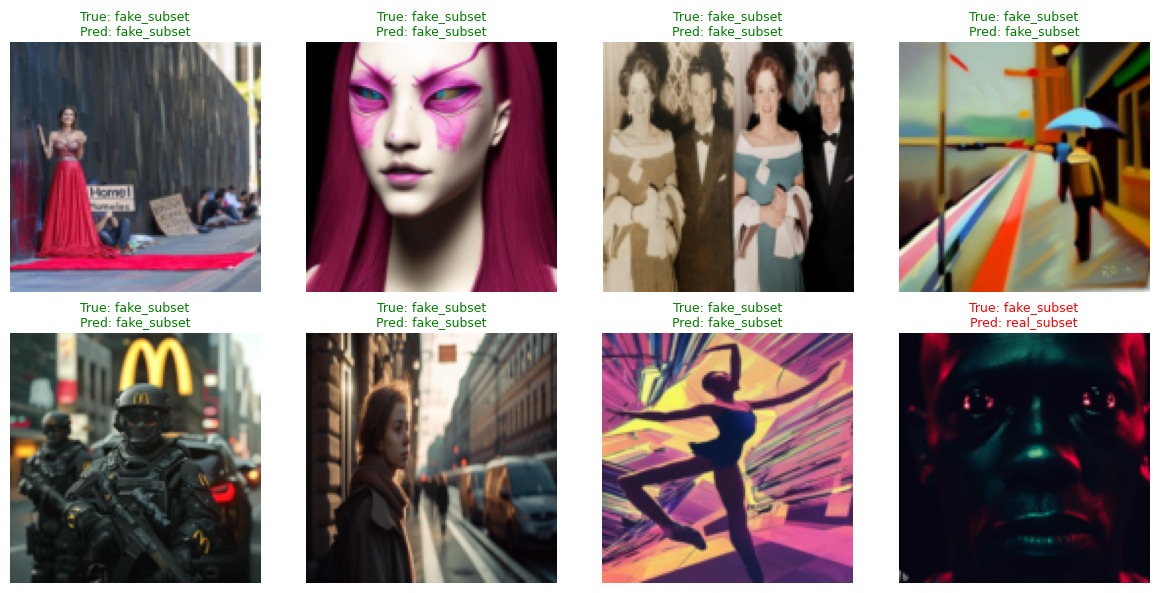

In [10]:
from src.evaluate import show_predictions

show_predictions(model1, test_loader, device, list(classes), num_examples=8)

## Experiment 2: Higher Dropout

Train with dropout=0.5 to reduce overfitting.

In [11]:
model2 = get_model(num_classes=2, dropout=0.5)
history2 = train_full(
    model2, train_loader, test_loader,
    num_epochs=5, lr=1e-3, device=device,
    save_path="checkpoints/exp2_high_dropout.pth"
)

Train: 100%|██████████| 63/63 [03:21<00:00,  3.20s/it, acc=64.8, loss=0.506]


Epoch 1/5 | Train Loss: 0.6399 Acc: 64.76% | Val Loss: 0.5748 Acc: 71.35%


Train: 100%|██████████| 63/63 [03:24<00:00,  3.25s/it, acc=67.3, loss=0.57]


Epoch 2/5 | Train Loss: 0.6130 Acc: 67.32% | Val Loss: 0.5532 Acc: 71.88%


Train: 100%|██████████| 63/63 [03:23<00:00,  3.23s/it, acc=68.4, loss=0.986]


Epoch 3/5 | Train Loss: 0.6078 Acc: 68.42% | Val Loss: 0.5861 Acc: 65.62%


Train: 100%|██████████| 63/63 [03:23<00:00,  3.23s/it, acc=71.5, loss=0.741]


Epoch 4/5 | Train Loss: 0.5814 Acc: 71.54% | Val Loss: 0.5902 Acc: 67.19%


Train: 100%|██████████| 63/63 [03:24<00:00,  3.24s/it, acc=70, loss=0.751]


Epoch 5/5 | Train Loss: 0.5732 Acc: 70.03% | Val Loss: 0.5680 Acc: 69.27%


In [13]:
# Evaluate Experiment 2
from src.evaluate import precision_recall_f1
model2.load_state_dict(torch.load("checkpoints/exp2_high_dropout.pth", map_location=device)["model_state_dict"])
y_true2, y_pred2, _ = evaluate(model2, test_loader, device)
acc2, cm2, report2 = get_metrics(y_true2, y_pred2, list(classes))
p2, r2, f1_2 = precision_recall_f1(y_true2, y_pred2)
print("Exp2 Test Accuracy:", acc2, "| Precision:", p2, "Recall:", r2, "F1:", f1_2)

Exp2 Test Accuracy: 0.71875 | Precision: 0.7188449848024316 Recall: 0.71875 F1: 0.7187194791101466


## Comparison: Experiment 1 vs 2

Comparison: Exp1 acc=0.7292 F1=0.7290 | Exp2 acc=0.7188 F1=0.7187


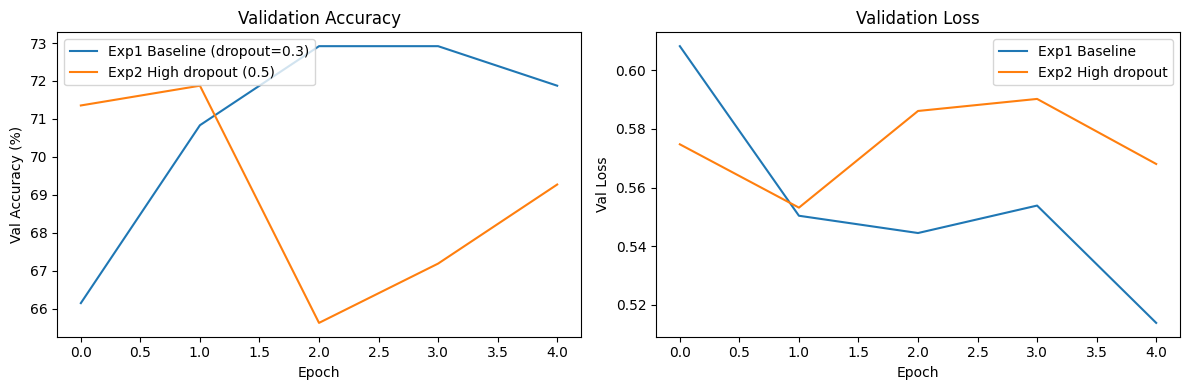

In [16]:
print("Comparison: Exp1 acc={:.4f} F1={:.4f} | Exp2 acc={:.4f} F1={:.4f}".format(acc, f1, acc2, f1_2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history1["val_acc"], label="Exp1 Baseline (dropout=0.3)")
axes[0].plot(history2["val_acc"], label="Exp2 High dropout (0.5)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Accuracy (%)")
axes[0].legend()
axes[0].set_title("Validation Accuracy")
axes[1].plot(history1["val_loss"], label="Exp1 Baseline")
axes[1].plot(history2["val_loss"], label="Exp2 High dropout")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Loss")
axes[1].legend()
axes[1].set_title("Validation Loss")
plt.tight_layout()
plt.show()